In [1]:
from facenet_pytorch import InceptionResnetV1
import PIL
from torchvision import transforms
from matplotlib import pyplot as plt
import torch
import onnxruntime as ort
import yaml
import faiss 

from insightface.app import FaceAnalysis
from tqdm import tqdm
import numpy as np
import os
from torch.nn import Module
from torch.utils.data import DataLoader,Dataset

option_path='config.yaml'
with open(option_path,'r') as file_option:
    files_option=yaml.safe_load(file_option)

/home/artemybombastic/Git/ZekNet/embedder_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#скачиваем веса
from insightface.app import FaceAnalysis
app = FaceAnalysis(name='buffalo_s') 
app.prepare(ctx_id=-1)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/artemybombastic/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionPr

In [3]:
#проверочка что нахожусь в нужно окружении
# import sys
# print(sys.executable)

In [4]:
# def img2tensor(img):
#     trans=transforms.Compose([
#         transforms.Resize((256,256)),
#         transforms.ToTensor()
#     ])
#     tensor=trans(img)
#     return tensor

In [23]:
class BuffaloModel(Module):
    def __init__(self, path,use_gpu=False):
        super().__init__()
        self.session=ort.InferenceSession(path)

        self.input_name=self.session.get_inputs()[0].name
        self.output_name=self.session.get_outputs()[0].name
    # def _preprocess(self,img):
    #     pass
    def forward(self,x):

        #разворот для буфало
        if x.ndim == 4:
            x = x[:, [2, 1, 0], :, :]
        else: # если пришла одна картинка [C, H, W]
            x = x[[2, 1, 0], :, :]

        x=x*255

            
        x = (x - 127.5) / 128.0
        x=x.numpy()
        output=self.session.run([self.output_name],{self.input_name:x})
        output=torch.from_numpy(output[0])
        output = torch.nn.functional.normalize(output, p=2, dim=1)
        return output
    

In [24]:
class TestDataset(Dataset):
    def __init__(self,path):
        super().__init__()

        self.trans=transforms.Compose([
            transforms.Resize((112,112)),
            transforms.ToTensor()
        ])

        self.images=[]
        for name in os.listdir(path):
            for filename in os.listdir(os.path.join(path,name)):
               self.images.append(os.path.join(os.path.join(path,name),filename))

    def __len__(self):
        return len(self.images)
    def __getitem__(self,idx):

        return self.trans(PIL.Image.open(self.images[idx]))
        

In [25]:
test_data=TestDataset(path=files_option['test_img_path'])

In [26]:
test_data[2]

tensor([[[0.7333, 0.7765, 0.7922,  ..., 0.7922, 0.6745, 0.5216],
         [0.6196, 0.7255, 0.7882,  ..., 0.7725, 0.6196, 0.5098],
         [0.4706, 0.6235, 0.7608,  ..., 0.7529, 0.5804, 0.5529],
         ...,
         [0.0078, 0.0078, 0.0078,  ..., 0.0941, 0.2000, 0.2588],
         [0.0078, 0.0078, 0.0078,  ..., 0.0824, 0.1686, 0.1686],
         [0.0196, 0.0078, 0.0078,  ..., 0.0667, 0.1176, 0.1451]],

        [[0.7216, 0.7529, 0.7608,  ..., 0.7725, 0.6510, 0.5098],
         [0.6078, 0.7059, 0.7569,  ..., 0.7490, 0.5961, 0.4980],
         [0.4549, 0.6039, 0.7294,  ..., 0.7294, 0.5608, 0.5412],
         ...,
         [0.0078, 0.0078, 0.0078,  ..., 0.0824, 0.1725, 0.2078],
         [0.0078, 0.0078, 0.0078,  ..., 0.0549, 0.1412, 0.1333],
         [0.0196, 0.0078, 0.0078,  ..., 0.0353, 0.0863, 0.1176]],

        [[0.7020, 0.7373, 0.7490,  ..., 0.7608, 0.6510, 0.5020],
         [0.5882, 0.6902, 0.7451,  ..., 0.7412, 0.5961, 0.4941],
         [0.4392, 0.5882, 0.7176,  ..., 0.7216, 0.5569, 0.

In [86]:
#embeder=InceptionResnetV1(pretrained='vggface2').eval()
embeder=BuffaloModel(path='/home/artemybombastic/.insightface/models/buffalo_s/w600k_mbf.onnx')

In [28]:
test_dataloader=DataLoader(dataset=test_data,batch_size=16,drop_last=False,shuffle=False)

In [69]:
embendings=[]
for batch in tqdm(test_dataloader):
    pred=embeder(batch)
    # pred=embeder(batch)
    embendings.append(pred.numpy())
    #embendings=np.append(embendings,1)
    #break
embendings = np.vstack(embendings).astype('float32')

100%|██████████████████████████████████████| 113/113 [00:58<00:00,  1.95it/s]


In [72]:
embendings.shape

(1800, 512)

In [47]:
#embendings=embendings.reshape(-1,512)

In [73]:
indexer=faiss.IndexFlatL2(512)
indexer.add(embendings)#добавляем базу

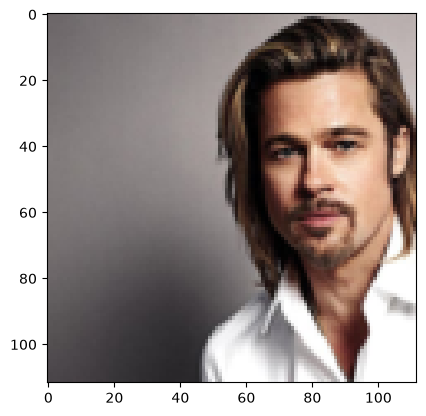

In [78]:
plt.imshow(test_data[500].permute(1,2,0))

In [82]:
similarities, indices=indexer.search(x=embendings[500].reshape(1,-1),k=3)

In [83]:
similarities

array([[0.        , 0.85649335, 0.8656994 ]], dtype=float32)

In [84]:
indices

array([[ 500, 1297,  598]])

In [58]:
data[indices.item()]

NameError: name 'data' is not defined

In [ ]:
1+1

In [ ]:
import numpy as np

# Список из 20 массивов по 16 элементов
batches = [np.random.rand(16) for _ in range(20)]

# Новый массив (320,)
result = np.concatenate(batches)


In [ ]:
len(batches)

In [ ]:
result.shape